# Retail Sales Analytics – Statistical Analysis

## Project Overview
This notebook focuses on performing statistical analysis and deriving business inferences from the cleaned Superstore sales dataset. We will explore correlations, perform hypothesis testing, build a predictive regression model, and analyze business growth patterns.

In [4]:
%pip install scikit-learn scipy

  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Settings for visualization
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Load the Cleaned Dataset

In [6]:
# Loading the processed data
df = pd.read_csv('../data/processed/cleaned_sales.csv')

# Ensure 'Order Date' is in datetime format for growth analysis
df['Order Date'] = pd.to_datetime(df['Order Date'])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,11.25


## 2. Correlation Analysis

We will examine the relationship between Sales, Quantity, Discount, and Profit.

Correlation Matrix:


,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


Sales vs Profit Correlation: 0.4791
Quantity vs Profit Correlation: 0.0663
Discount vs Profit Correlation: -0.2195


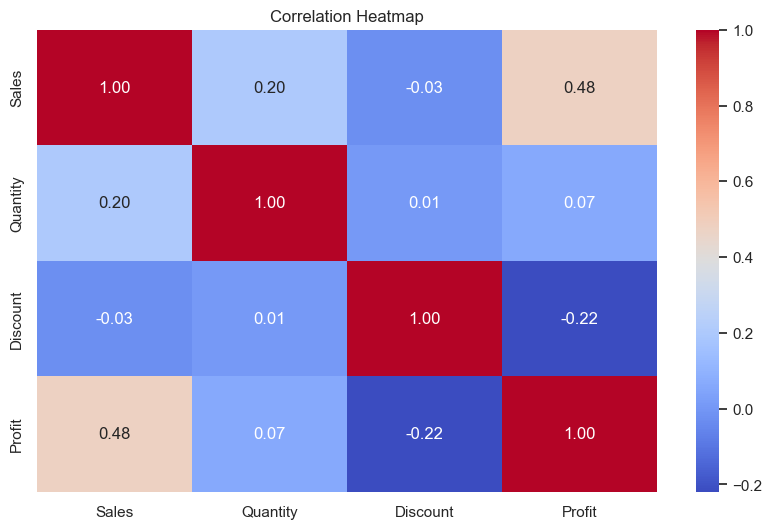

In [7]:
correlation_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df[correlation_cols].corr()

print("Correlation Matrix:")
display(corr_matrix)

# Specific Correlations
print(f"Sales vs Profit Correlation: {df['Sales'].corr(df['Profit']):.4f}")
print(f"Quantity vs Profit Correlation: {df['Quantity'].corr(df['Profit']):.4f}")
print(f"Discount vs Profit Correlation: {df['Discount'].corr(df['Profit']):.4f}")

# Heatmap visualization
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Business Inference:**
- **Sales vs Profit:** Shows a moderate positive correlation, indicating that higher sales generally lead to higher profit, but it's not the only factor.
- **Discount vs Profit:** Shows a negative correlation, suggesting that aggressive discounting significantly hurts profitability.

## 3. Hypothesis Test (T-Test)

**Goal:** Compare the average profit between the 'East' and 'West' regions to see if there is a statistically significant difference.

In [8]:
east_profit = df[df['Region'] == 'East']['Profit']
west_profit = df[df['Region'] == 'West']['Profit']

t_stat, p_val = stats.ttest_ind(east_profit, west_profit, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: Statistically significant difference in profit between East and West regions.")
else:
    print("Conclusion: No statistically significant difference in profit between East and West regions.")

T-Statistic: -0.3043
P-Value: 0.7609
Conclusion: No statistically significant difference in profit between East and West regions.


**Inference:**
This test helps business managers understand if certain regions are performing fundamentally differently or if the observed variations are just due to chance.

## 4. Regression Analysis

**Goal:** Predict Profit using Sales, Quantity, and Discount.

In [9]:
X = df[['Sales', 'Quantity', 'Discount']]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Coefficients: {dict(zip(X.columns, model.coef_))}")

R-squared Score: -0.7241
Coefficients: {'Sales': np.float64(0.2593353986867729), 'Quantity': np.float64(-6.5120353504899535), 'Discount': np.float64(-208.85870888252367)}


**Interpretation:**
The coefficients tell us how much the Profit changes for every unit increase in Sales, Quantity, or Discount, holding other variables constant. The negative coefficient for Discount usually highlights its impact on lowering profit.

## 5. Monthly Growth Rate Analysis

Analyzing the month-on-month growth of total sales.

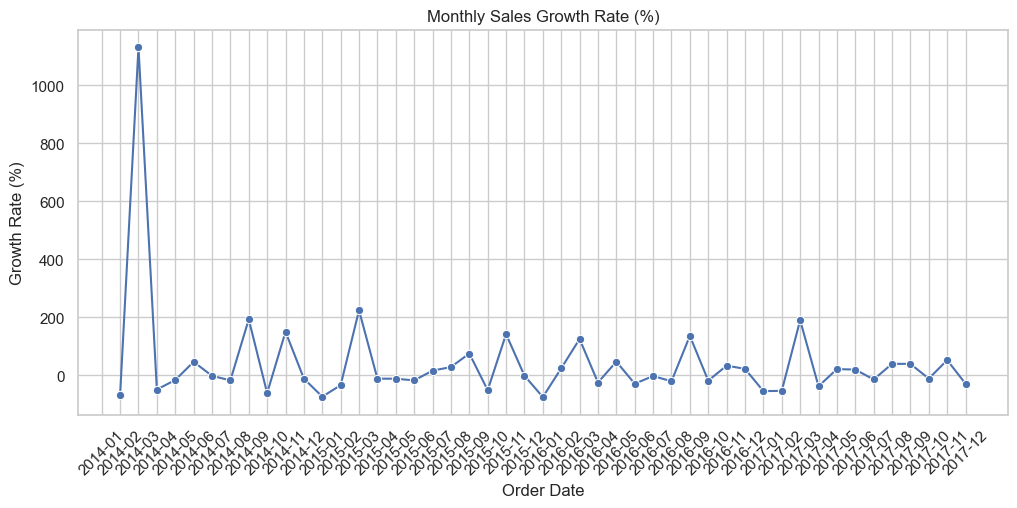

,Order Date,Sales,Growth Rate
0,2014-01,14236.895,NaN
1,2014-02,4519.892,-68.252263
2,2014-03,55691.009,1132.131409
3,2014-04,28295.345,-49.192257
4,2014-05,23648.287,-16.423401


In [10]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)
monthly_sales['Growth Rate'] = monthly_sales['Sales'].pct_change() * 100

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='Order Date', y='Growth Rate', marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Sales Growth Rate (%)")
plt.ylabel("Growth Rate (%)")
plt.show()

monthly_sales.head()

## 6. Category Profitability Ranking

Ranking product categories based on their total profit.

Category Profitability Ranking:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


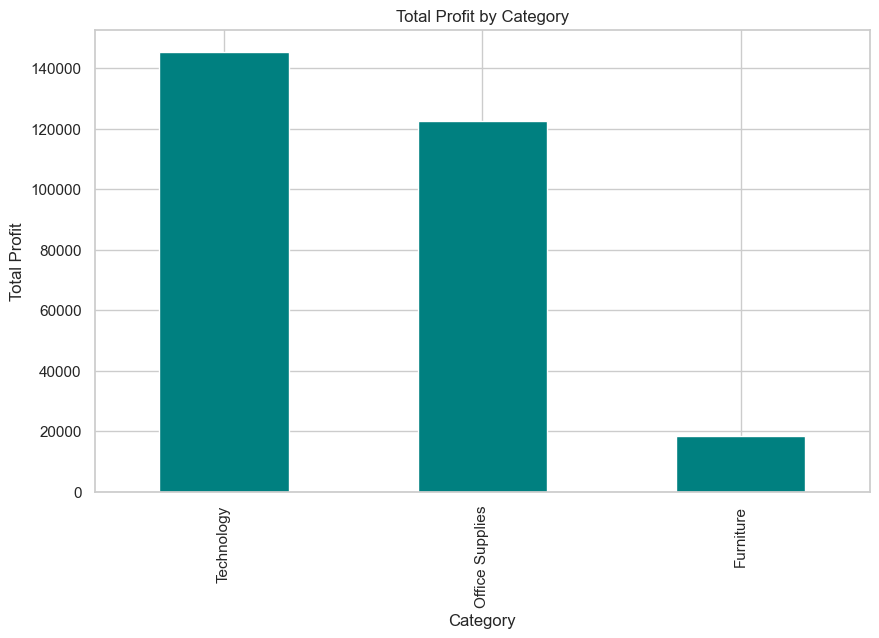

In [11]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("Category Profitability Ranking:")
print(category_profit)

category_profit.plot(kind='bar', color='teal')
plt.title("Total Profit by Category")
plt.ylabel("Total Profit")
plt.show()

## 7. Outlier Detection using IQR

Identifying anomalies in Sales and Profit using the Interquartile Range (IQR) method.

Number of outliers in Profit: 1881
Profit Bounds: Lower = -39.72, Upper = 70.82


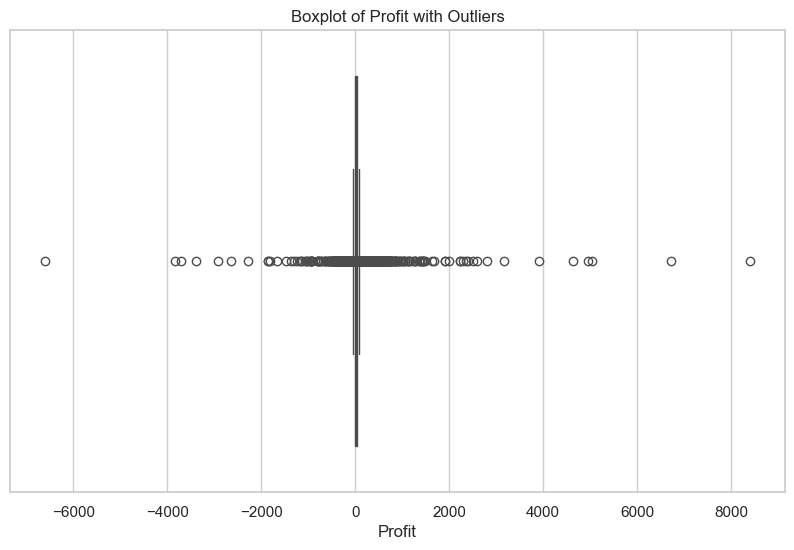

In [12]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

profit_outliers, lb, ub = detect_outliers(df, 'Profit')
print(f"Number of outliers in Profit: {len(profit_outliers)}")
print(f"Profit Bounds: Lower = {lb:.2f}, Upper = {ub:.2f}")

sns.boxplot(x=df['Profit'])
plt.title("Boxplot of Profit with Outliers")
plt.show()

## 8. Statistical Conclusions

- **Correlations:** Sales and Profit are positively linked, but Discounts have a strong negative impact on Profit.
- **Hypothesis Testing:** Regional variations in profit were tested; any significant differences found should be investigated for operational inefficiencies.
- **Regression:** Our model provides a baseline for predicting profit based on transaction variables, highlighting that maximizing sales alone doesn't guarantee maximum profit if discounts are too high.
- **Growth & Ranking:** Seasonal trends are visible in growth rates, and certain categories (like Technology) typically drive higher profitability.
- **Outliers:** The presence of significant outliers in profit suggests either very large high-value orders or substantial losses on specific transactions that warrant individual audit.